In [1]:
PROJ_NAME = "dilithium_poly_decompose_ttest"
LABEL = ""
OFFSET = 0

In [2]:
import sys
sys.path.insert(0, "../")
from host.ttest_trace_collector import TTestTraceCollector

In [3]:
trace_collector = TTestTraceCollector(proj_name=PROJ_NAME, label=LABEL, input_len=32,
                                      output_len=0, offset=OFFSET)

In [5]:
trace_collector.init_target(force=False)

(ChipWhisperer NAEUSB WARNING|File naeusb.py:800) Your firmware (0.51) is outdated - latest is 0.53 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information


In [6]:
trace_collector.default_setup(40E6, 12, 40000)

In [7]:
trace_collector.build_fw()
trace_collector.program_fw()

-DDILITHIUM_MODE=3 -DTTEST -DBUSY_CHECK_DIS -DSS_VER=1 -O3 -I../../../../fw/dilithium_hw -I../victims_commons -I../../driver -I../../simpleserial -I../../../../sdk/lib -march=rv32im -mabi=ilp32 -mstrict-align -T ../../../../sdk/toolchain/linksc.ld -flto -ffunction-sections -fdata-sections -nostartfiles -o dilithium_poly_decompose_ttest.elf
/opt/riscv/bin/riscv64-unknown-elf-gcc dilithium_poly_decompose_ttest.c ../../../../fw/dilithium_hw/packing.c ../../../../fw/dilithium_hw/poly.c ../../../../fw/dilithium_hw/polyvec.c ../../../../fw/dilithium_hw/randombytes.c ../../../../fw/dilithium_hw/sign.c ../../../../fw/dilithium_hw/symmetric.c ../../../../fw/dilithium_hw/reduce.c ../../../../fw/dilithium_hw/masked.c ../../../../fw/dilithium_hw/masked_sign.c ../../../../fw/dilithium_hw/masked_poly.c ../../../../fw/dilithium_hw/masked_polyvec.c ../../../../fw/dilithium_hw/masked_gadgets.c ../../../../fw/dilithium_hw/masked_packing.c ../../../../fw/dilithium_hw/masked_symmetric.c ../victims_commons

../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.inst.bin: 100%|██████████| 4.37k/4.37k [00:00<00:00, 12.9kB/s]
../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.data.bin: 100%|██████████| 1.07k/1.07k [00:00<00:00, 10.5kB/s]


File transmission complete for ../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.inst.bin.
Sending file: ../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.data.bin
File transmission complete for ../fw/victims/dilithium_poly_decompose_ttest/dilithium_poly_decompose_ttest.data.bin.
Program load complete.
Serial port closed.


# PRNG=OFF

In [8]:
trace_collector.collect_traces(N=1000, prng_off=True, overwrite=True, check_output=False)

Capturing traces:   0%|          | 0/1000 [00:00<?, ?it/s]

In [9]:
ttest_analysis_off = trace_collector.get_analysis_obj(N=1000, prng_off=True)

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/dilithium_poly_decompose_ttest_N1000_prngoff1_r0_o0_.ets with 1000 traces.
s................: uint8

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/dilithium_poly_decompose_ttest_N1000_prngoff1_r1_o0_.ets with 1000 traces.
s................: uint8



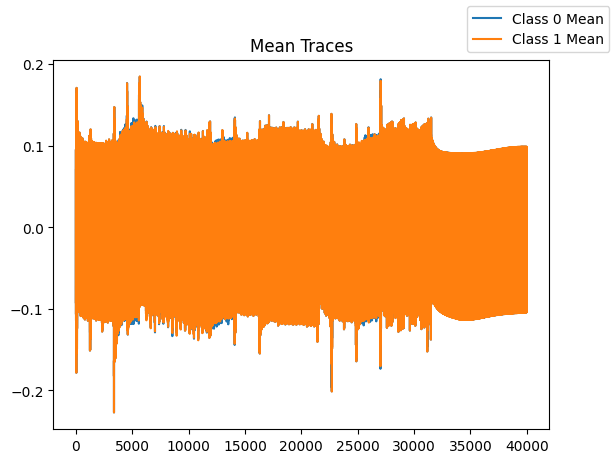

In [10]:
ttest_analysis_off.plot_means()

In [11]:
ttest_analysis_off.run_ttest()

Running T-Test: 100%|██████████| 1/1 [00:01<00:00,  1.01s/it]


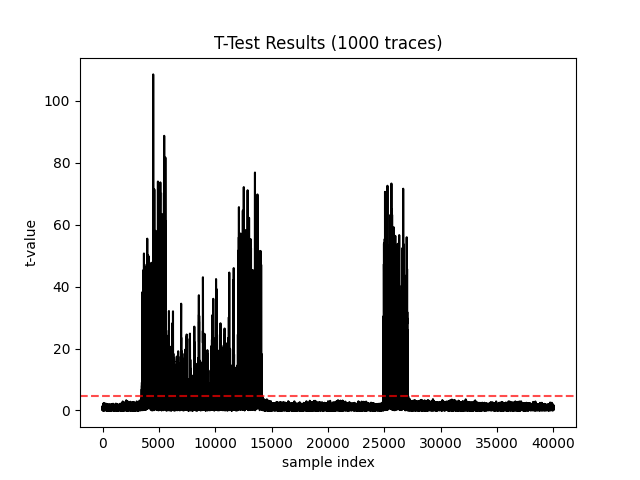

In [13]:
%matplotlib widget
ttest_analysis_off.plot_ttest()

# PRNG=ON

In [8]:
trace_collector.collect_traces(N=100000, prng_off=False, overwrite=True, check_output=False)

Capturing traces:   0%|          | 0/100000 [00:00<?, ?it/s]

ERROR:estraces.formats.ets_writer:Exception raised during init of h5f file: Unable to synchronously open file (file is already open for write (may use <h5clear file> to clear file consistency flags)).
ERROR:estraces.formats.ets_writer:Exception raised during init of h5f file: Unable to synchronously open file (file is already open for write (may use <h5clear file> to clear file consistency flags)).


KeyboardInterrupt: 

In [ ]:
ttest_analysis_on = trace_collector.get_analysis_obj(N=10, prng_off=False)

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_poly_tomsg_ttest_N10_prngoff0_r0_newx2x with 10 traces.
s................: float64

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_poly_tomsg_ttest_N10_prngoff0_r1_newx2x with 10 traces.
s................: float64



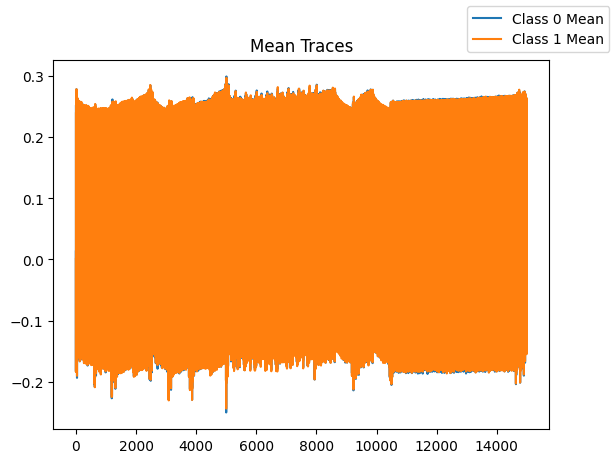

In [ ]:
ttest_analysis_on.plot_means()

In [ ]:
ttest_analysis_on.run_ttest()

/home/toluntosun/miniconda3/envs/sca/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


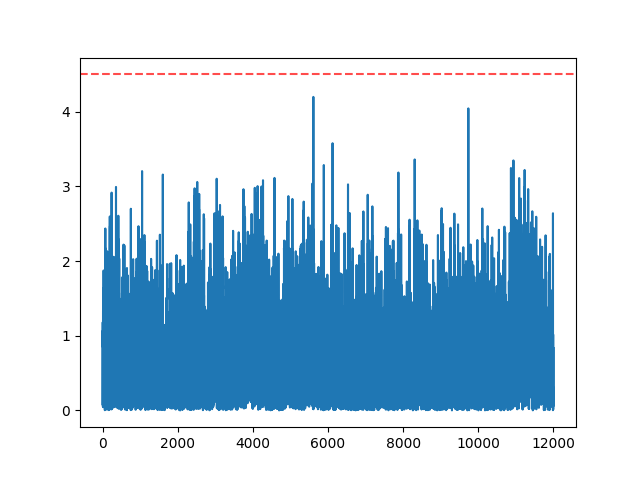

In [ ]:
ttest_analysis_on.plot_ttest(ylimit=10)